Shortcut to make a multiline comment: ctrl + /


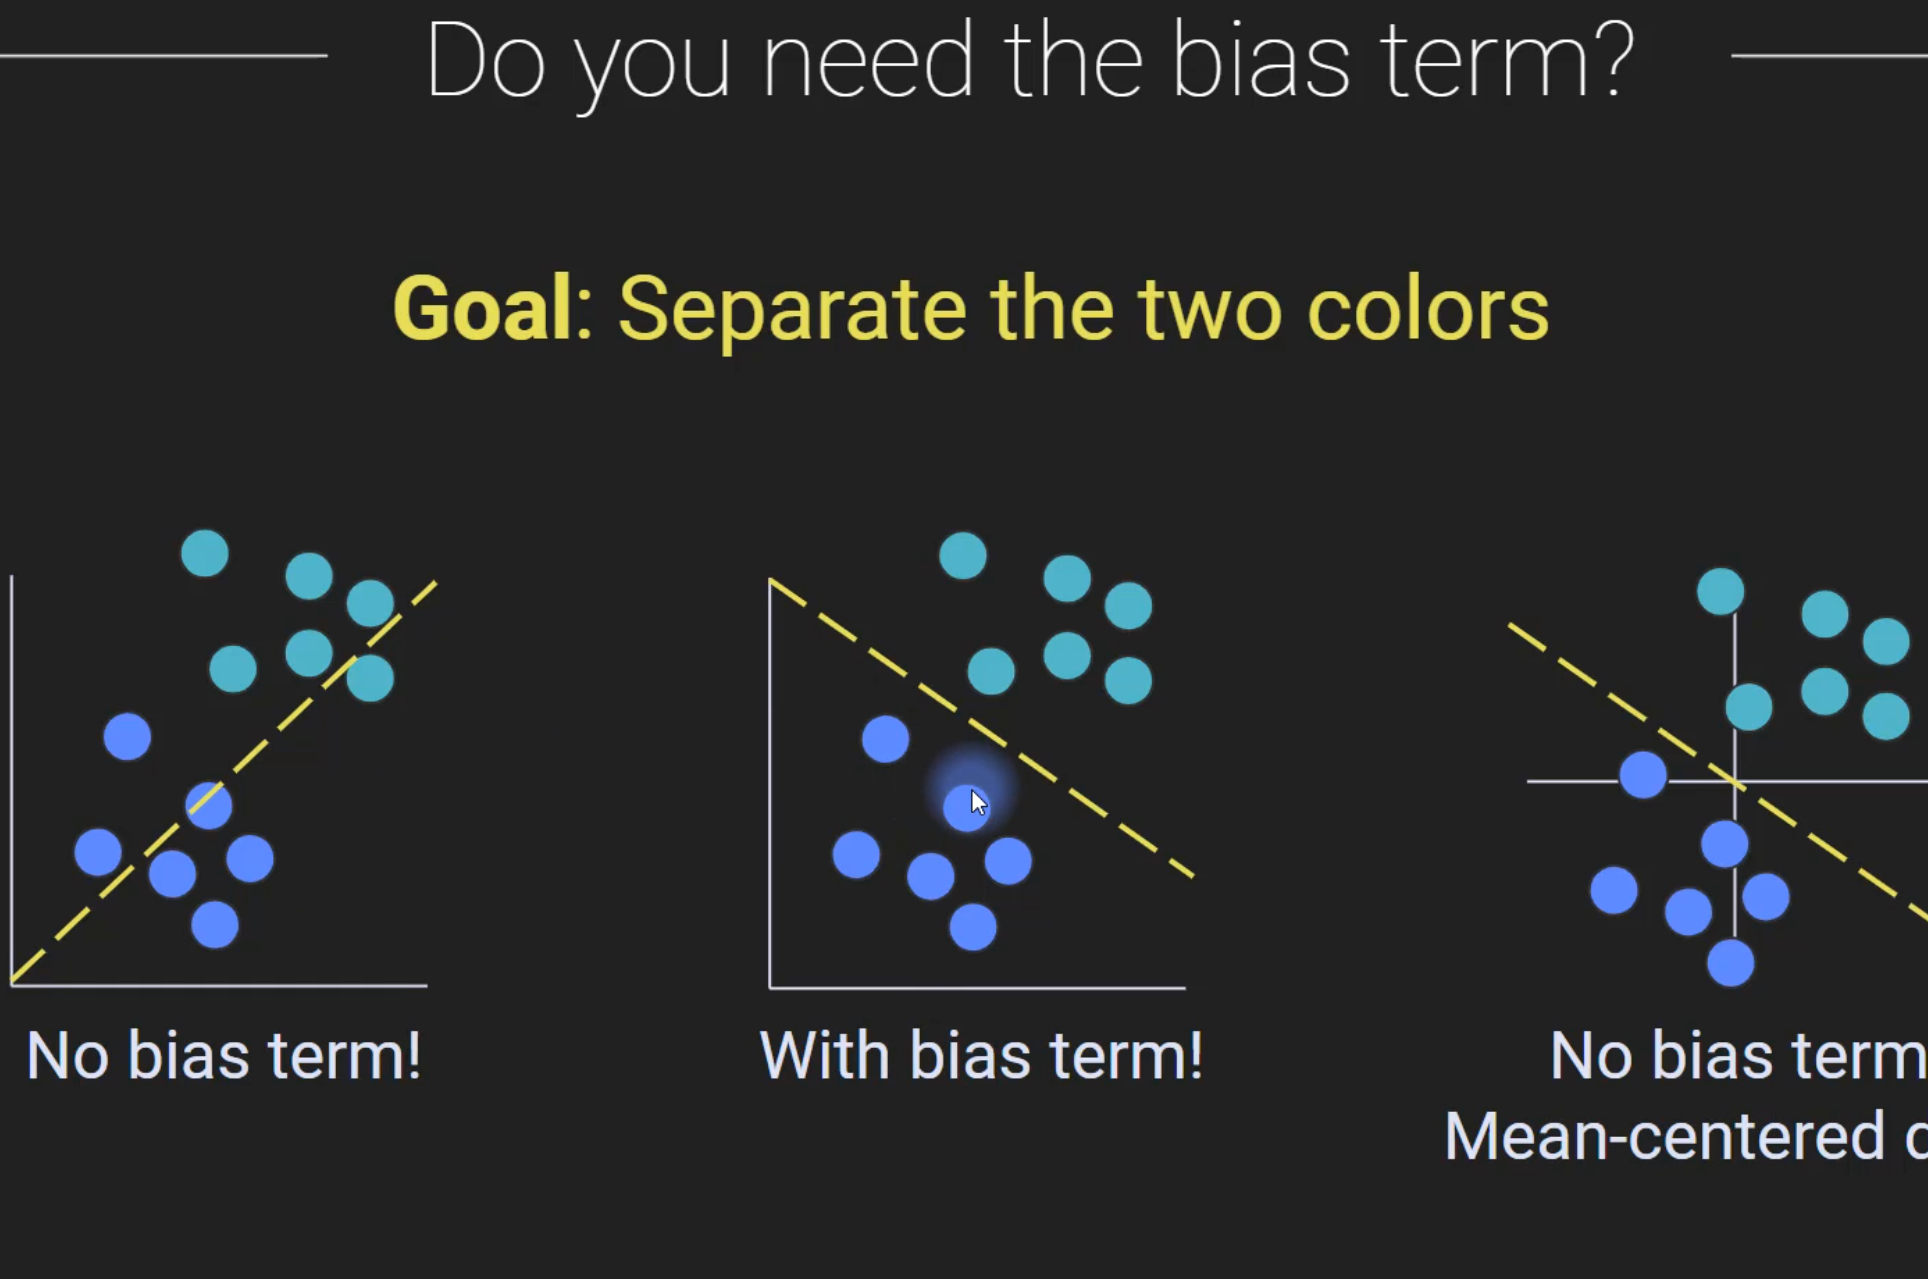

Instead of a bias term we can mean-centred out data but it is not ideal for all situations.


- Mean Squared Error(MSE) : output is a numerical prediction
- Cross entropy (logistic) : categorical data when the output is a probability

cost function is a average of lost function for the sample.

The goal is to find weight (learnable parameters) such that we minimaize the cost function. 

BCE: binary cross entropy 

- ReLU for internal activation function
- Sigmoid for last layer actication in binary classification

Categorization:
- Single category categorization (sigmoid as the last activation), probabilities: p and 1-p
- Multi category categorization (softmax as the last activation), probabilities sum up to 1

In [4]:
# !pip install seaborn
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
data = torch.tensor( iris[iris.columns[0:4]].values ).float()

# transform species to number
labels = torch.zeros(len(data), dtype=torch.long)
# labels[iris.species=='setosa'] = 0 # don't need!
labels[iris.species=='versicolor'] = 1
labels[iris.species=='virginica'] = 2
labels

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2])

In [10]:
ANNiris = nn.Sequential(
    nn.Linear(4,64),   # input layer
    nn.ReLU(),         # activation
    nn.Linear(64,64),  # hidden layer
    nn.ReLU(),         # activation
    nn.Linear(64,3),   # output layer
      )

# loss function
lossfun = nn.CrossEntropyLoss()

# optimizer
optimizer = torch.optim.SGD(ANNiris.parameters(),lr=.01)
numepochs = 1000

# initialize losses
losses = torch.zeros(numepochs)
ongoingAcc = []

# loop over epochs
for epochi in range(numepochs):

  # forward pass
  yHat = ANNiris(data)

  # compute loss
  loss = lossfun(yHat,labels)
  losses[epochi] = loss

  # backprop
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # compute accuracy
  matches = torch.argmax(yHat,axis=1) == labels # booleans (false/true)
  matchesNumeric = matches.float()              # convert to numbers (0/1)
  accuracyPct = 100*torch.mean(matchesNumeric)  # average and x100
  ongoingAcc.append( accuracyPct )              # add to list of accuracies



# final forward pass
predictions = ANNiris(data)

predlabels = torch.argmax(predictions,axis=1)
totalacc = 100*torch.mean((predlabels == labels).float())
torch.argmax(yHat,axis=1)


tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1,
        2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2])

Final accuracy: 98%


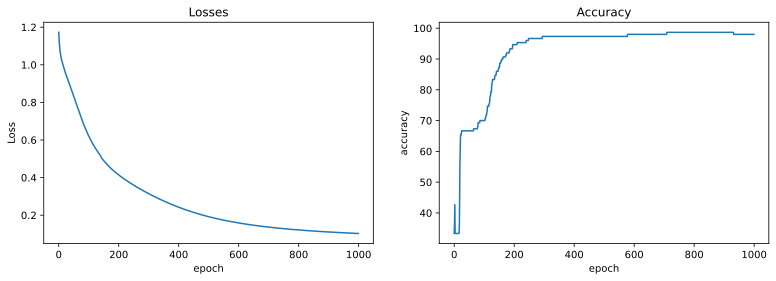

In [11]:
print('Final accuracy: %g%%' %totalacc)

fig,ax = plt.subplots(1,2,figsize=(13,4))

ax[0].plot(losses.detach())
ax[0].set_ylabel('Loss')
ax[0].set_xlabel('epoch')
ax[0].set_title('Losses')

ax[1].plot(ongoingAcc)
ax[1].set_ylabel('accuracy')
ax[1].set_xlabel('epoch')
ax[1].set_title('Accuracy')
plt.show()

Researcher degree of frrdom means many choices to clean, organize and select data and model which is problematic. One problem is overfitting. (reduces generalizability)

- k fold cross validation: k is the size of test against the training set
- overfitting: the gap of model performance between the result from training set and test is the level of overfitting. 


Regularization:
- Penalizing memorization (over leanring) 
- Help model generalize to unseen exmaples
- Can decrese training accuracy but increase generalization
- Add cost to the complexity of the solution (forcing smooth solutions)


3 forms of regularization:
- Node regularization: modify the model (dropout: remove nodes by setting their activation to zero)
- Loss regularization: add cost to the loss fucntion (L1 or L2 regularization) : makign sure the weights are close to zero. Cost = average(Loss) + regularzer term 
- Data regularization: modift or add data (batch training, data augmentation)


- Gradients are computed only during backprop, not during evaluation.
- Some regularizain methods are applied only during training, not during evaluation.

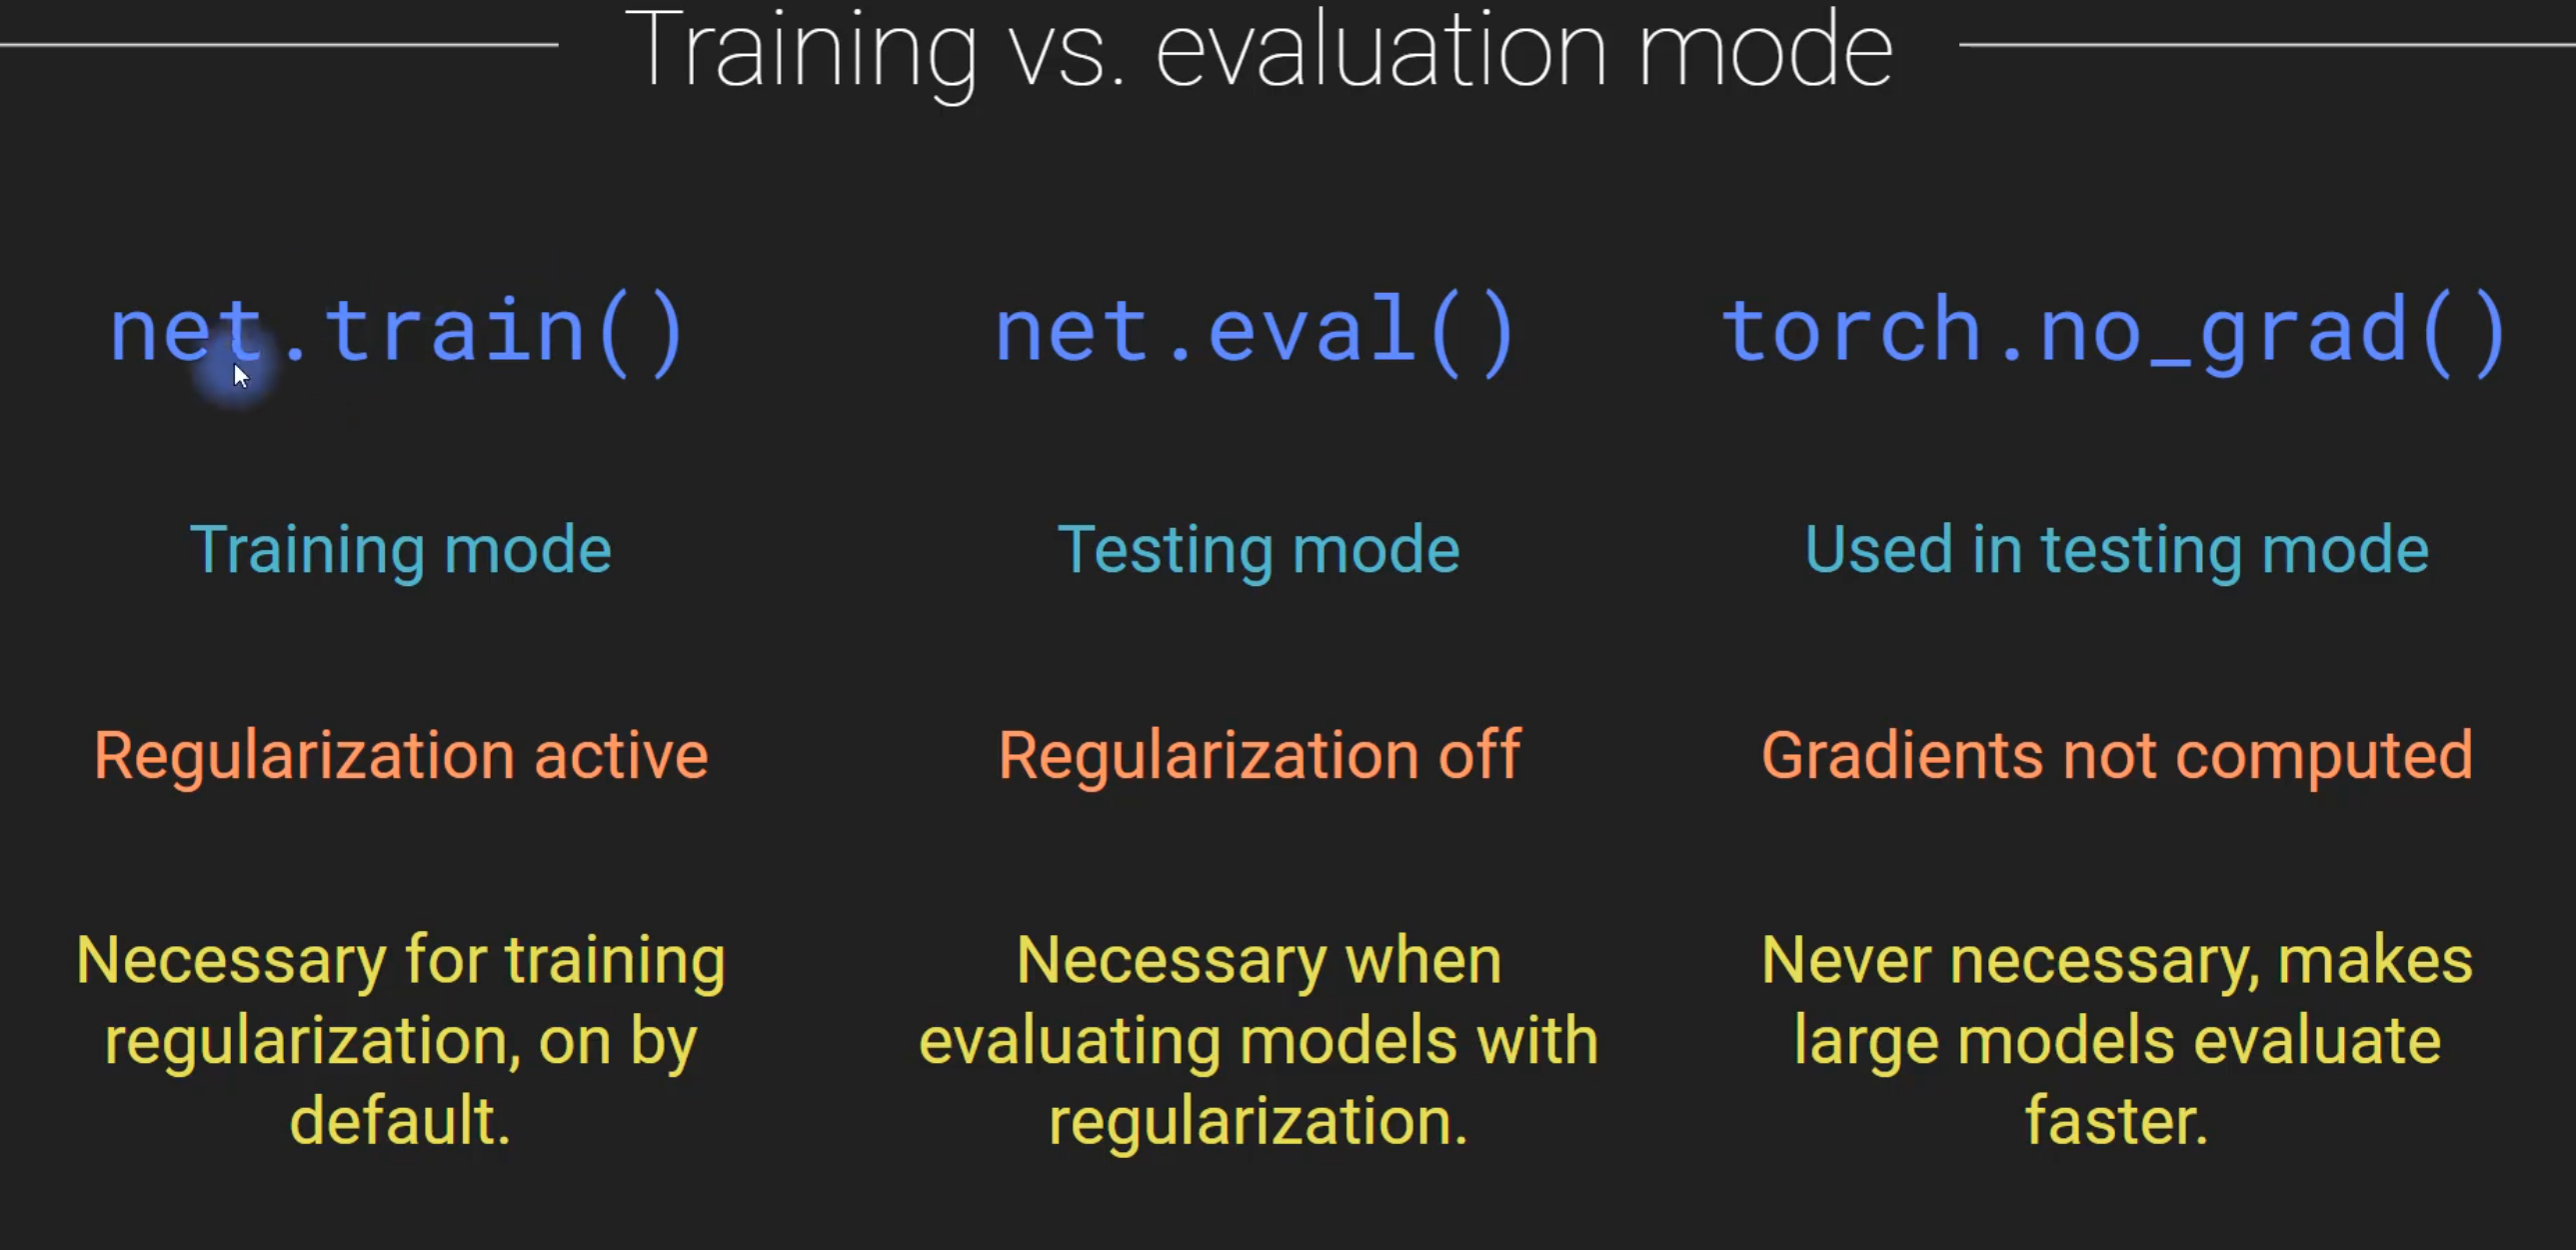



- Parameters: Features of the model that are learned by the alogorithm (weight, biases) and you do not set them
- Metaparameters: Features of the model that are set by you. Not learned automatically (architecture, loss functions, etc.)

### Normalization


- z-normalization / z-transform: Mean center, varience-normalize : used for **normally distributed** data
- min-maxscaling : min becomes zero, max becomes 1 : used for images and **uniform** data

Batch normalization: nomalize inputs to each layer (usually before activation function but after is also possible). Makes the model performs better specially in deeper NN

- Sigmoid is not so great in hidden layers
- softmax (multiclass categorisation) is the same as sigmoid (binary classification) when number of categories are 2. 

